In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [3]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_inf   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_inf.npy')
dir_inf = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_inf.npy')
U_disk   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_disk.npy')
dir_disk = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_disk.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
# wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
pitch  = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/pitch.npy')
# Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
# Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
# rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
# R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

wrf_tsr = 2 * np.pi / 60 * 99.5 / 7 * wrf_omg

In [4]:
indices = [14,15,16,17,18,19,20]

In [5]:
Nelm = 30
Nsct = 160

In [12]:
casenames[17]

np.str_('s000_v000')

In [6]:
veers = np.array([-0.2,-0.13,-0.067,0.0,0.067,0.13,0.2] )

In [7]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction

In [8]:
# LES Baseline

rotor = IEA10MW()

base_les_ind = np.zeros_like(indices, dtype='float')
base_les_cot = np.zeros_like(indices, dtype='float')
base_les_thr = np.zeros_like(indices, dtype='float')
base_les_cop = np.zeros_like(indices, dtype='float')
base_les_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_ind)):

    print(f'case: {count}')

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers[count])
    # sol = bem(0, 10.63, 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers[count])

    base_les_cot[count] = sol.Ct()
    base_les_thr[count] = sol.thrust()/1e3
    base_les_pow[count] = sol.power()/1e6
    base_les_cop[count] = sol.Cp()
    base_les_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

case: 0
case: 1
case: 2
case: 3
case: 4
case: 5
case: 6


array([6., 6., 6., 6., 6., 6., 6.])

In [27]:
base_les_pow

array([3.11530908, 3.1589698 , 3.18212032, 3.17940928, 3.14201801,
       3.08151076, 2.99938375])

In [9]:
base_les_pow

array([3.124939  , 3.16526111, 3.1846372 , 3.18019511, 3.14429891,
       3.08609752, 3.00277002])

In [10]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ClassicalMomentum

In [11]:
# 1D Momentum Baseline

rotor = IEA10MW()

# indices = np.arange(len(casenames))

base_1D_ind = np.zeros_like(indices, dtype='float')
base_1D_cot = np.zeros_like(indices, dtype='float')
base_1D_thr = np.zeros_like(indices, dtype='float')
base_1D_cop = np.zeros_like(indices, dtype='float')
base_1D_pow = np.zeros_like(indices, dtype='float')
iters       = np.zeros_like(indices, dtype='float')

for count in range(len(base_1D_ind)):
    print(count)

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ClassicalMomentum(averaging='rotor'), tangential_induction_model=NoTangentialInduction())

    # sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count])
    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index])

    base_1D_cot[count] = sol.Ct()
    base_1D_thr[count] = sol.thrust()/1e3
    base_1D_pow[count] = sol.power()/1e6
    base_1D_cop[count] = sol.Cp()
    base_1D_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

0
1
2
3
4
5
6


array([11., 11., 11., 11., 11., 12., 12.])

In [23]:
base_1D_pow 

array([3.1985083 , 3.18400036, 3.17092257, 3.16235045, 3.14759099,
       3.12871576, 3.11394322])

In [12]:
base_1D_pow 

array([3.20097054, 3.18628567, 3.17296617, 3.15878933, 3.14462408,
       3.13194402, 3.1174434 ])

In [62]:
base_1D_cot

array([0.89254272, 0.89395632, 0.89524186, 0.89588845, 0.8971082 ,
       0.89889283, 0.90025509, 0.89255031, 0.89396756, 0.89525534,
       0.89590944, 0.89713189, 0.89891234, 0.90027684, 0.89309165,
       0.89451976, 0.89520308, 0.89645019, 0.89766254, 0.89949103,
       0.90086093, 0.89346026, 0.89488407, 0.89551944, 0.89675775,
       0.89797293, 0.89982676, 0.90119925, 0.89321788, 0.89463804,
       0.89528247, 0.89652174, 0.89773727, 0.89957853, 0.90094834])

In [63]:
base_1D_ind

array([0.33570663, 0.33669733, 0.33758938, 0.33909319, 0.34013968,
       0.34061838, 0.34159402, 0.3357195 , 0.33671203, 0.33760498,
       0.3391057 , 0.3401531 , 0.34063815, 0.34161648, 0.33612095,
       0.33711856, 0.33849266, 0.33954402, 0.34060571, 0.34105368,
       0.34202241, 0.33636934, 0.33736173, 0.33876569, 0.33981635,
       0.34087356, 0.3413075 , 0.34228443, 0.33618831, 0.33718011,
       0.3385752 , 0.33962373, 0.34067861, 0.34111979, 0.34209539])

In [13]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, MadsenMomentum

In [14]:
# Madsen Baseline

rotor = IEA10MW()

base_mad_ind = np.zeros_like(indices, dtype='float')
base_mad_cot = np.zeros_like(indices, dtype='float')
base_mad_thr = np.zeros_like(indices, dtype='float')
base_mad_cop = np.zeros_like(indices, dtype='float')
base_mad_pow = np.zeros_like(indices, dtype='float')
iters        = np.zeros_like(indices, dtype='float')

for count in range(len(base_mad_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=MadsenMomentum(averaging='rotor'), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count])

    base_mad_cot[count] = sol.Ct()
    base_mad_thr[count] = sol.thrust()/1e3
    base_mad_pow[count] = sol.power()/1e6
    base_mad_cop[count] = sol.Cp()
    base_mad_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([6., 6., 6., 6., 6., 6., 6.])

In [28]:
base_mad_pow

array([3.24586747, 3.23290314, 3.22115601, 3.2086739 , 3.19625179,
       3.18463677, 3.17188383])

In [15]:
base_mad_pow

array([3.24838726, 3.23536123, 3.22354784, 3.21096592, 3.19841808,
       3.18668565, 3.17379026])

In [17]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction_GP_CTprime

In [18]:
rotor = IEA10MW()

gpr_ind = np.zeros_like(indices, dtype='float')
gpr_cot = np.zeros_like(indices, dtype='float')
gpr_thr = np.zeros_like(indices, dtype='float')
gpr_cop = np.zeros_like(indices, dtype='float')
gpr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')


inds = np.array([0.35290458,0.34369589, 0.33851808, 0.33742325,0.34160368, 0.34977288, 0.36218143])

for count in range(len(gpr_ind)):
# for count in [17]:

# for count in [3]:

    index = indices[count]
    # index = 17
    # count=3
    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers[count]), tangential_induction_model=NoTangentialInduction())

    # sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count], a_init=inds[count]*np.ones_like(dir_inf[:,:,index]))
    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count])

    gpr_cot[count] = sol.Ct()
    gpr_thr[count] = sol.thrust()/1e3
    gpr_pow[count] = sol.power()/1e6
    gpr_cop[count] = sol.Cp()
    gpr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([3., 3., 4., 4., 3., 3., 3.])

In [9]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction_GP_CTprime

In [12]:
rotor = IEA10MW()

gpr_ind = np.zeros_like(indices, dtype='float')
gpr_cot = np.zeros_like(indices, dtype='float')
gpr_thr = np.zeros_like(indices, dtype='float')
gpr_cop = np.zeros_like(indices, dtype='float')
gpr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')


inds = np.array([0.35290458,0.34369589, 0.33851808, 0.33742325,0.34160368, 0.34977288, 0.36218143])

for count in range(len(gpr_ind)):
# for count in [17]:

# for count in [3]:

    index = indices[count]
    # index = 17
    # count=3
    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers[count]), tangential_induction_model=NoTangentialInduction())

    # sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count], a_init=inds[count]*np.ones_like(dir_inf[:,:,index]))
    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count])

    gpr_cot[count] = sol.Ct()
    gpr_thr[count] = sol.thrust()/1e3
    gpr_pow[count] = sol.power()/1e6
    gpr_cop[count] = sol.Cp()
    gpr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

0.34999999999999987
0.8851282154664859
0.3508207248216886
0.8841102262177819
0.35150770471574044
0.8832578302065753
0.3520836137847854
0.8825431161005666
0.3525670586138439
0.881943070276012
0.35297334607223213
0.8814387257939056
0.35331511229779183
0.8810144241193429
0.35360282926407205
0.8806571922262857
0.35384520589399854
0.8803562304494977
0.3540495006181003
0.8801025386798869
0.35422177770226526
0.87988859749791
0.35436711389775644
0.8797081039056066
0.3544897629869945
0.8795557789661665
0.3545932953082391
0.879427192821047
0.35468071160628317
0.8793186186471628
0.34999999999999987
0.8823345484051706
0.34877527999222974
0.8838885686170744
0.34776435042007564
0.8851703182181478
0.34693162058363075
0.886225791119288
0.3462470028222078
0.8870928759991755
0.34568486708728385
0.8878043142202414
0.3452237511088941
0.8883876753594071
0.3448458580136381
0.8888656208439901
0.34453641755683573
0.8892569078183623
0.344283200009608
0.8895770553652235
0.34407610805739736
0.8898388558439824
0.

array([14., 14., 16., 16., 15.,  4., 19.])

In [15]:
gpr_ind

array([0.35475453, 0.34348783, 0.33805056, 0.33716119, 0.34109617,
       0.34939375, 0.36364037])

In [16]:
gpr_cot

array([0.87922693, 0.89058238, 0.89689895, 0.89952654, 0.89819239,
       0.89301962, 0.88312518])

In [7]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction_GP_CTprime

In [12]:
rotor = IEA10MW()

gpr_ind = np.zeros_like(indices, dtype='float')
gpr_cot = np.zeros_like(indices, dtype='float')
gpr_thr = np.zeros_like(indices, dtype='float')
gpr_cop = np.zeros_like(indices, dtype='float')
gpr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')


inds = np.array([0.35290458,0.34369589, 0.33851808, 0.33742325,0.34160368, 0.34977288, 0.36218143])

for count in range(len(gpr_ind)):
# for count in [17]:

# for count in [3]:

    index = indices[count]
    # index = 17
    # count=3
    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers[count]), tangential_induction_model=NoTangentialInduction())

    # sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count], a_init=inds[count]*np.ones_like(dir_inf[:,:,index]))
    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers[count])

    gpr_cot[count] = sol.Ct()
    gpr_thr[count] = sol.thrust()/1e3
    gpr_pow[count] = sol.power()/1e6
    gpr_cop[count] = sol.Cp()
    gpr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

[np.float64(0.34999999999999987), np.float64(2.0720625283676624)]
[0.34314223]
[np.float64(0.34451378650542114), np.float64(2.0537978340265446)]
[0.34314223]
[np.float64(0.34341654380650544), np.float64(2.0501767891382805)]
[0.34314223]
[np.float64(0.3431970952667222), np.float64(2.0494539151838884)]
[0.34314223]
[np.float64(0.34999999999999987), np.float64(2.078166886856006)]
[0.33929272]
[np.float64(0.3414341782955615), np.float64(2.0497840897529036)]
[0.33929272]
[np.float64(0.33972101395467375), np.float64(2.0441787848772655)]
[0.33929272]
[np.float64(0.3393783810864961), np.float64(2.0430613261715465)]
[0.33929272]
[np.float64(0.34999999999999987), np.float64(2.0837193086449535)]
[0.33731607]
[np.float64(0.33985285783197816), np.float64(2.0501808129686503)]
[0.33731607]
[np.float64(0.3378234293983737), np.float64(2.0435747522169767)]
[0.33731607]
[np.float64(0.33741754371165267), np.float64(2.0422586518108843)]
[0.33731607]
[np.float64(0.33733636657430865), np.float64(2.0419956353

array([3., 3., 4., 4., 3., 3., 3.])

In [11]:
gpr_ind

array([0.34315321, 0.33930985, 0.33732013, 0.3374742 , 0.34032133,
       0.34528974, 0.35253342])

In [81]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

scaled_dict = {}
scalers_dict = {}

def compute_regimes(shear, veer, suffix):
    regimes = (
        (shear.flatten() != 0).astype(int) * 2 + (veer.flatten() != 0).astype(int)
    ).reshape(-1, 1)

    encoder = OneHotEncoder(sparse_output=False)
    onehot = encoder.fit_transform(regimes)
    scalers_dict[f'encoder_{suffix}'] = encoder

    scaled_dict[f'shear_regime_{suffix}'] = onehot

compute_regimes(np.array([0.0]),np.array([-0.067]),'rotor')

scaled_dict

{'shear_regime_rotor': array([[1.]])}

In [62]:
gpr_ind

array([0.        , 0.        , 0.        , 0.32504005, 0.        ,
       0.        , 0.        ])

In [118]:
gpr_pow = gpr_pow * 0.944

In [24]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, GP_Annulus

In [27]:
rotor = IEA10MW()

gpa_ind = np.zeros_like(indices, dtype='float')
gpa_cot = np.zeros_like(indices, dtype='float')
gpa_thr = np.zeros_like(indices, dtype='float')
gpa_cop = np.zeros_like(indices, dtype='float')
gpa_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

gpa_ind_a = np.zeros((Nelm,len(indices)), dtype='float')
gpa_cot_a = np.zeros((Nelm,len(indices)), dtype='float')

for count in range(len(gpa_ind)):
# for count in [4]:

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=GP_Annulus(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, 9.59, 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    gpa_cot[count] = sol.Ct()
    gpa_thr[count] = sol.thrust()/1e3
    gpa_pow[count] = sol.power()/1e6
    gpa_cop[count] = sol.Cp()
    gpa_ind[count] = sol.a()
    iters[count]   = sol.niter

    gpa_ind_a[:,count] = sol.a('annulus')
    gpa_cot_a[:,count] = sol.Ct('annulus')

iters

AttributeError: 'numpy.ndarray' object has no attribute 'C_x'

In [168]:
gpa_pow

array([3.09172113, 3.11815444, 3.11848963, 3.11329227, 3.12188274,
       3.09823773, 3.08815397, 3.05647136, 2.96507554])

In [15]:
np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/wrf_ind_ann.npy')

array([[0.02505624, 0.02160859, 0.02177606, ..., 0.02229271, 0.02634228,
        0.03899398],
       [0.01138334, 0.00788872, 0.00806968, ..., 0.00669677, 0.01079605,
        0.02365014],
       [0.03726974, 0.03440164, 0.03510936, ..., 0.04214369, 0.04803543,
        0.06525613],
       ...,
       [0.1349138 , 0.12762911, 0.12624779, ..., 0.12596514, 0.12969847,
        0.142928  ],
       [0.09527242, 0.08740569, 0.08576784, ..., 0.0845747 , 0.08810629,
        0.101028  ],
       [0.05346516, 0.04488632, 0.04294824, ..., 0.04022299, 0.04352194,
        0.05612402]], shape=(26, 63), dtype=float128)

In [ ]:
num_calls = 8
save_dir = '/scratch/09909/smata/temp_4'

all_Ct = [np.load(f'{save_dir}/Ct_{i:04d}.npy') for i in range(num_calls)]
all_a  = [np.load(f'{save_dir}/a_{i:04d}.npy')  for i in range(num_calls)]

In [ ]:
all_a

[array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
        0.24898454, 0.21468291, 0.17743089, 0.13890931, 0.09716235,
        0.0544846 ]),
 array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
        0.24898454, 0.21468291, 0.17743089, 0.13890931, 0.09716235,
        0.0544846 ]),
 array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
    

Text(0.5, 0, '$a$ [-]')

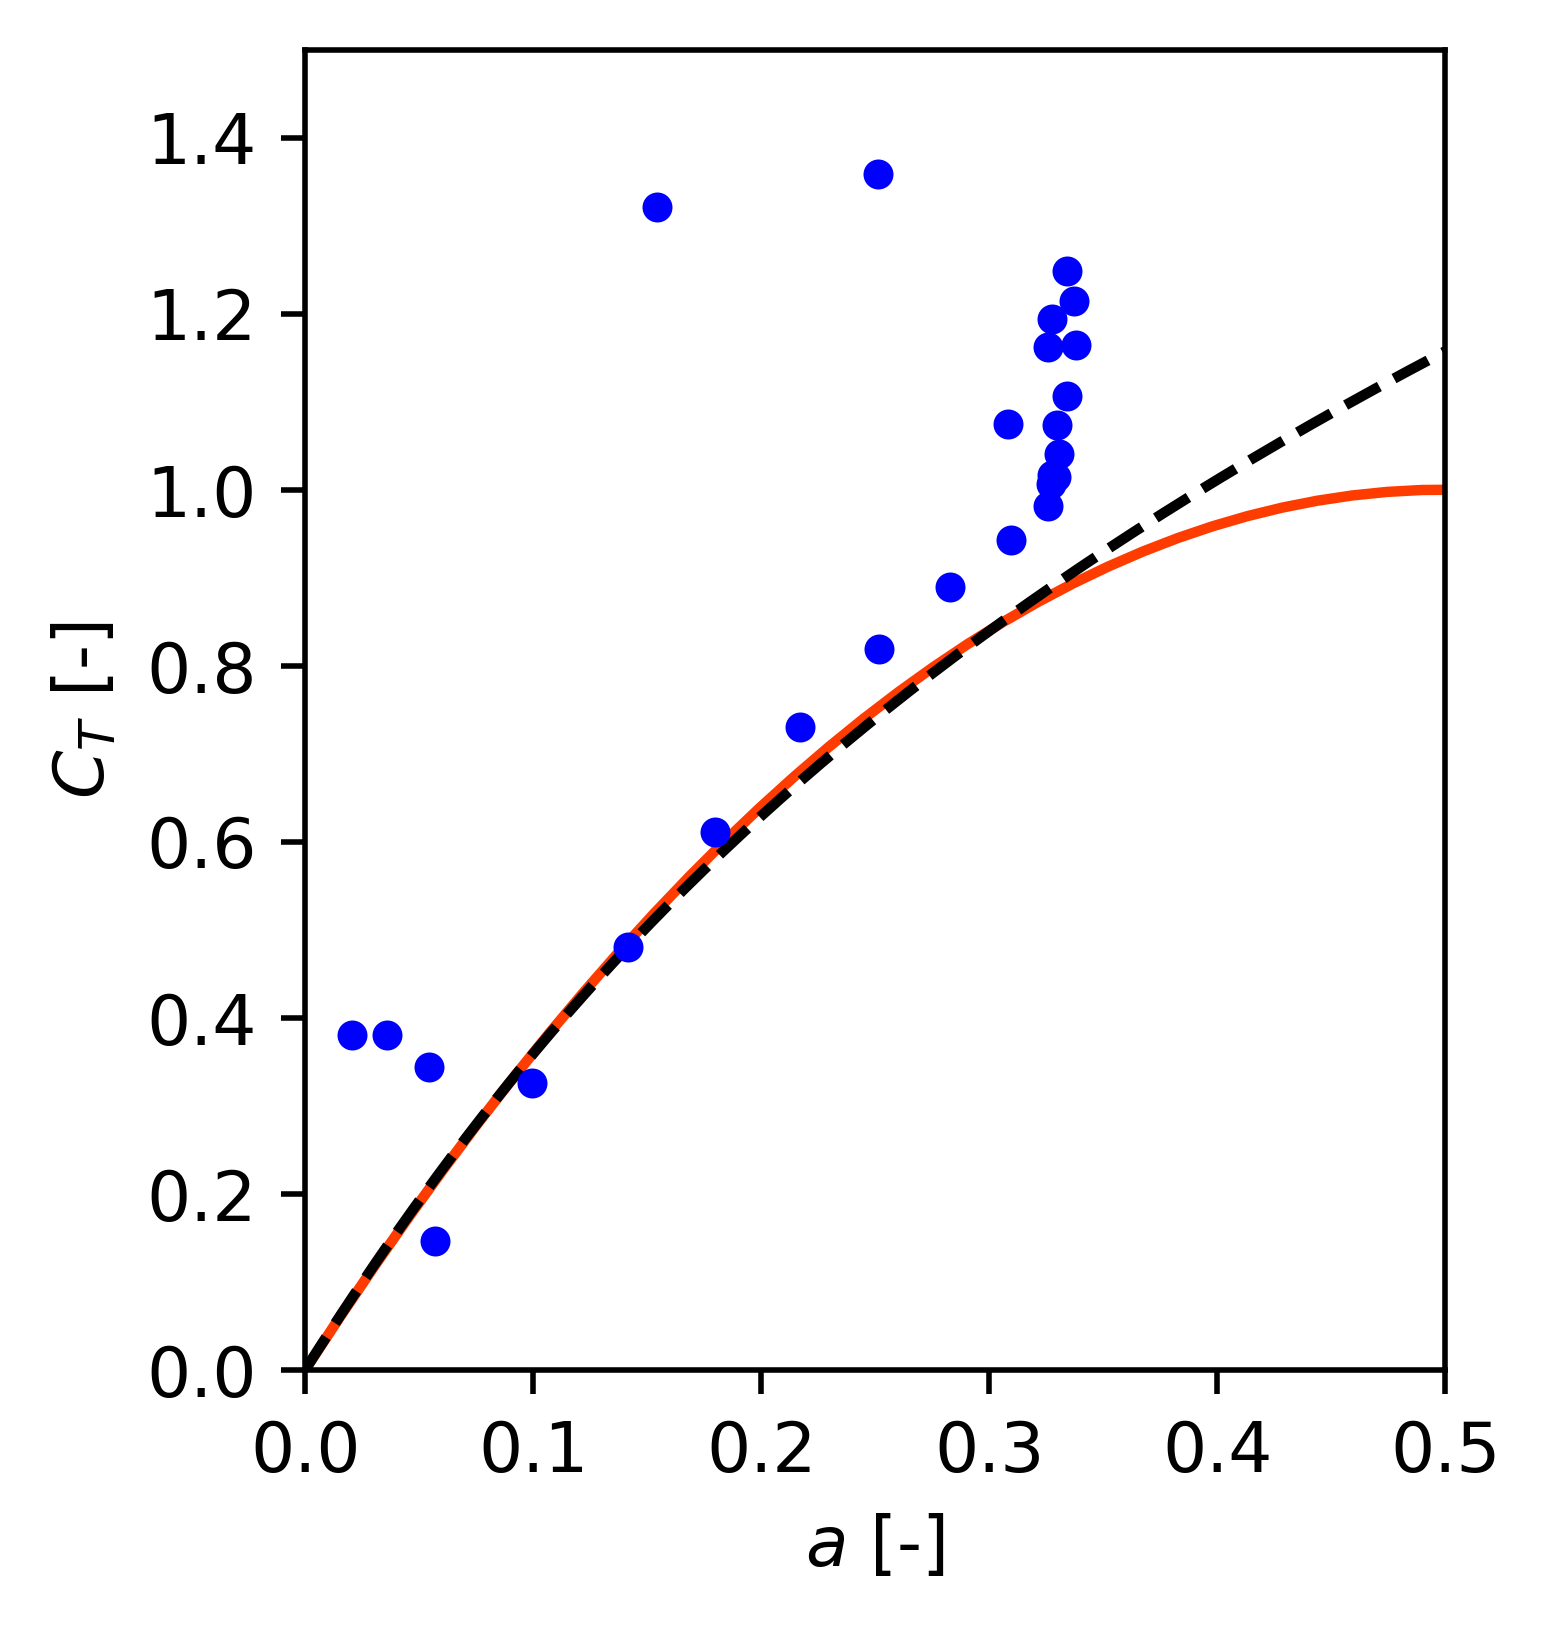

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd

# === Reference curves ===
a_mom = np.linspace(0, 0.75, 50)
ct_mom = 4 * a_mom * (1 - a_mom)

a_vals = gpa_ind_a[:,4]
ct_vals = gpa_cot_a[:,4]

# a_vals = gpa_ind
# ct_vals = gpa_cot

ct_mad = np.linspace(0, 1.5, 75)
k1, k2, k3 = 0.2460, 0.0586, 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

# === Setup figure ===
fig, ax = plt.subplots(figsize=(3, 3))
fig.subplots_adjust(left=0.22, right=0.98, top=0.98, bottom=0.1)  # Adjust as needed

ax.plot(a_mom, ct_mom, '#ff3c00', zorder=1, label='Classical Momentum')
ax.plot(a_mad, ct_mad, 'k--', zorder=1, label='Madsen Model')
scatter_plot, = ax.plot([], [], 'ro', markersize=1, label='GP prediction')
ax.scatter(a_vals, ct_vals,11,color='b',label='Training data')

# # ax.set_xlim([0, 0.5])
# # ax.set_ylim([0.625, 0.8])
ax.set_xlim([0,0.5])
ax.set_ylim([0,1.5])
ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
# # ax.legend(loc='lower right', fontsize=6)

# # === Animation update function ===
# # def update(frame):
# #     scatter_plot.set_data(all_a[:frame+1], all_Ct[:frame+1])
# #     return scatter_plot,

# # === Create dynamic text elements ===
# iteration_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
#                          ha='left', va='top', fontsize=8)
# rmse_text = ax.text(0.02, 0.935, '', transform=ax.transAxes,
#                     ha='left', va='top', fontsize=8)

# # === RMSE helper ===
# def rmse(y_pred, y_true):
#     return np.sqrt(np.mean((y_pred - y_true)**2))

# # === Animation update function ===
# def update(frame):
#     a_pred = all_a[frame]
#     ct_pred = all_Ct[frame]

#     scatter_plot.set_data(a_pred, ct_pred)

#     rmse_a = rmse(a_pred, a_vals)
#     rmse_ct = rmse(ct_pred, ct_vals)

#     iteration_text.set_text(f'Iteration: {frame}')
#     rmse_text.set_text(f'RMSE: a={rmse_a:.4f}, Ct={rmse_ct:.4f}')
#     return scatter_plot, iteration_text, rmse_text

# ani = FuncAnimation(fig, update, frames=len(all_a), interval=200, blit=True)

# # === Save to MP4 ===
# # ani.save("/home1/09909/smata/dir_scratch/ann_search_n025.gif", writer='pillow', fps=3, dpi=300)
# ani.save("/home1/09909/smata/dir_scratch/ann_search_000.gif", writer='pillow', fps=3, dpi=300)

In [20]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

[Text(0, 0, '$-0.2$'),
 Text(1, 0, '$-0.1$'),
 Text(2, 0, '$-0.05$'),
 Text(3, 0, '$0$'),
 Text(4, 0, '$0.05$'),
 Text(5, 0, '$0.1$'),
 Text(6, 0, '$0.2$')]

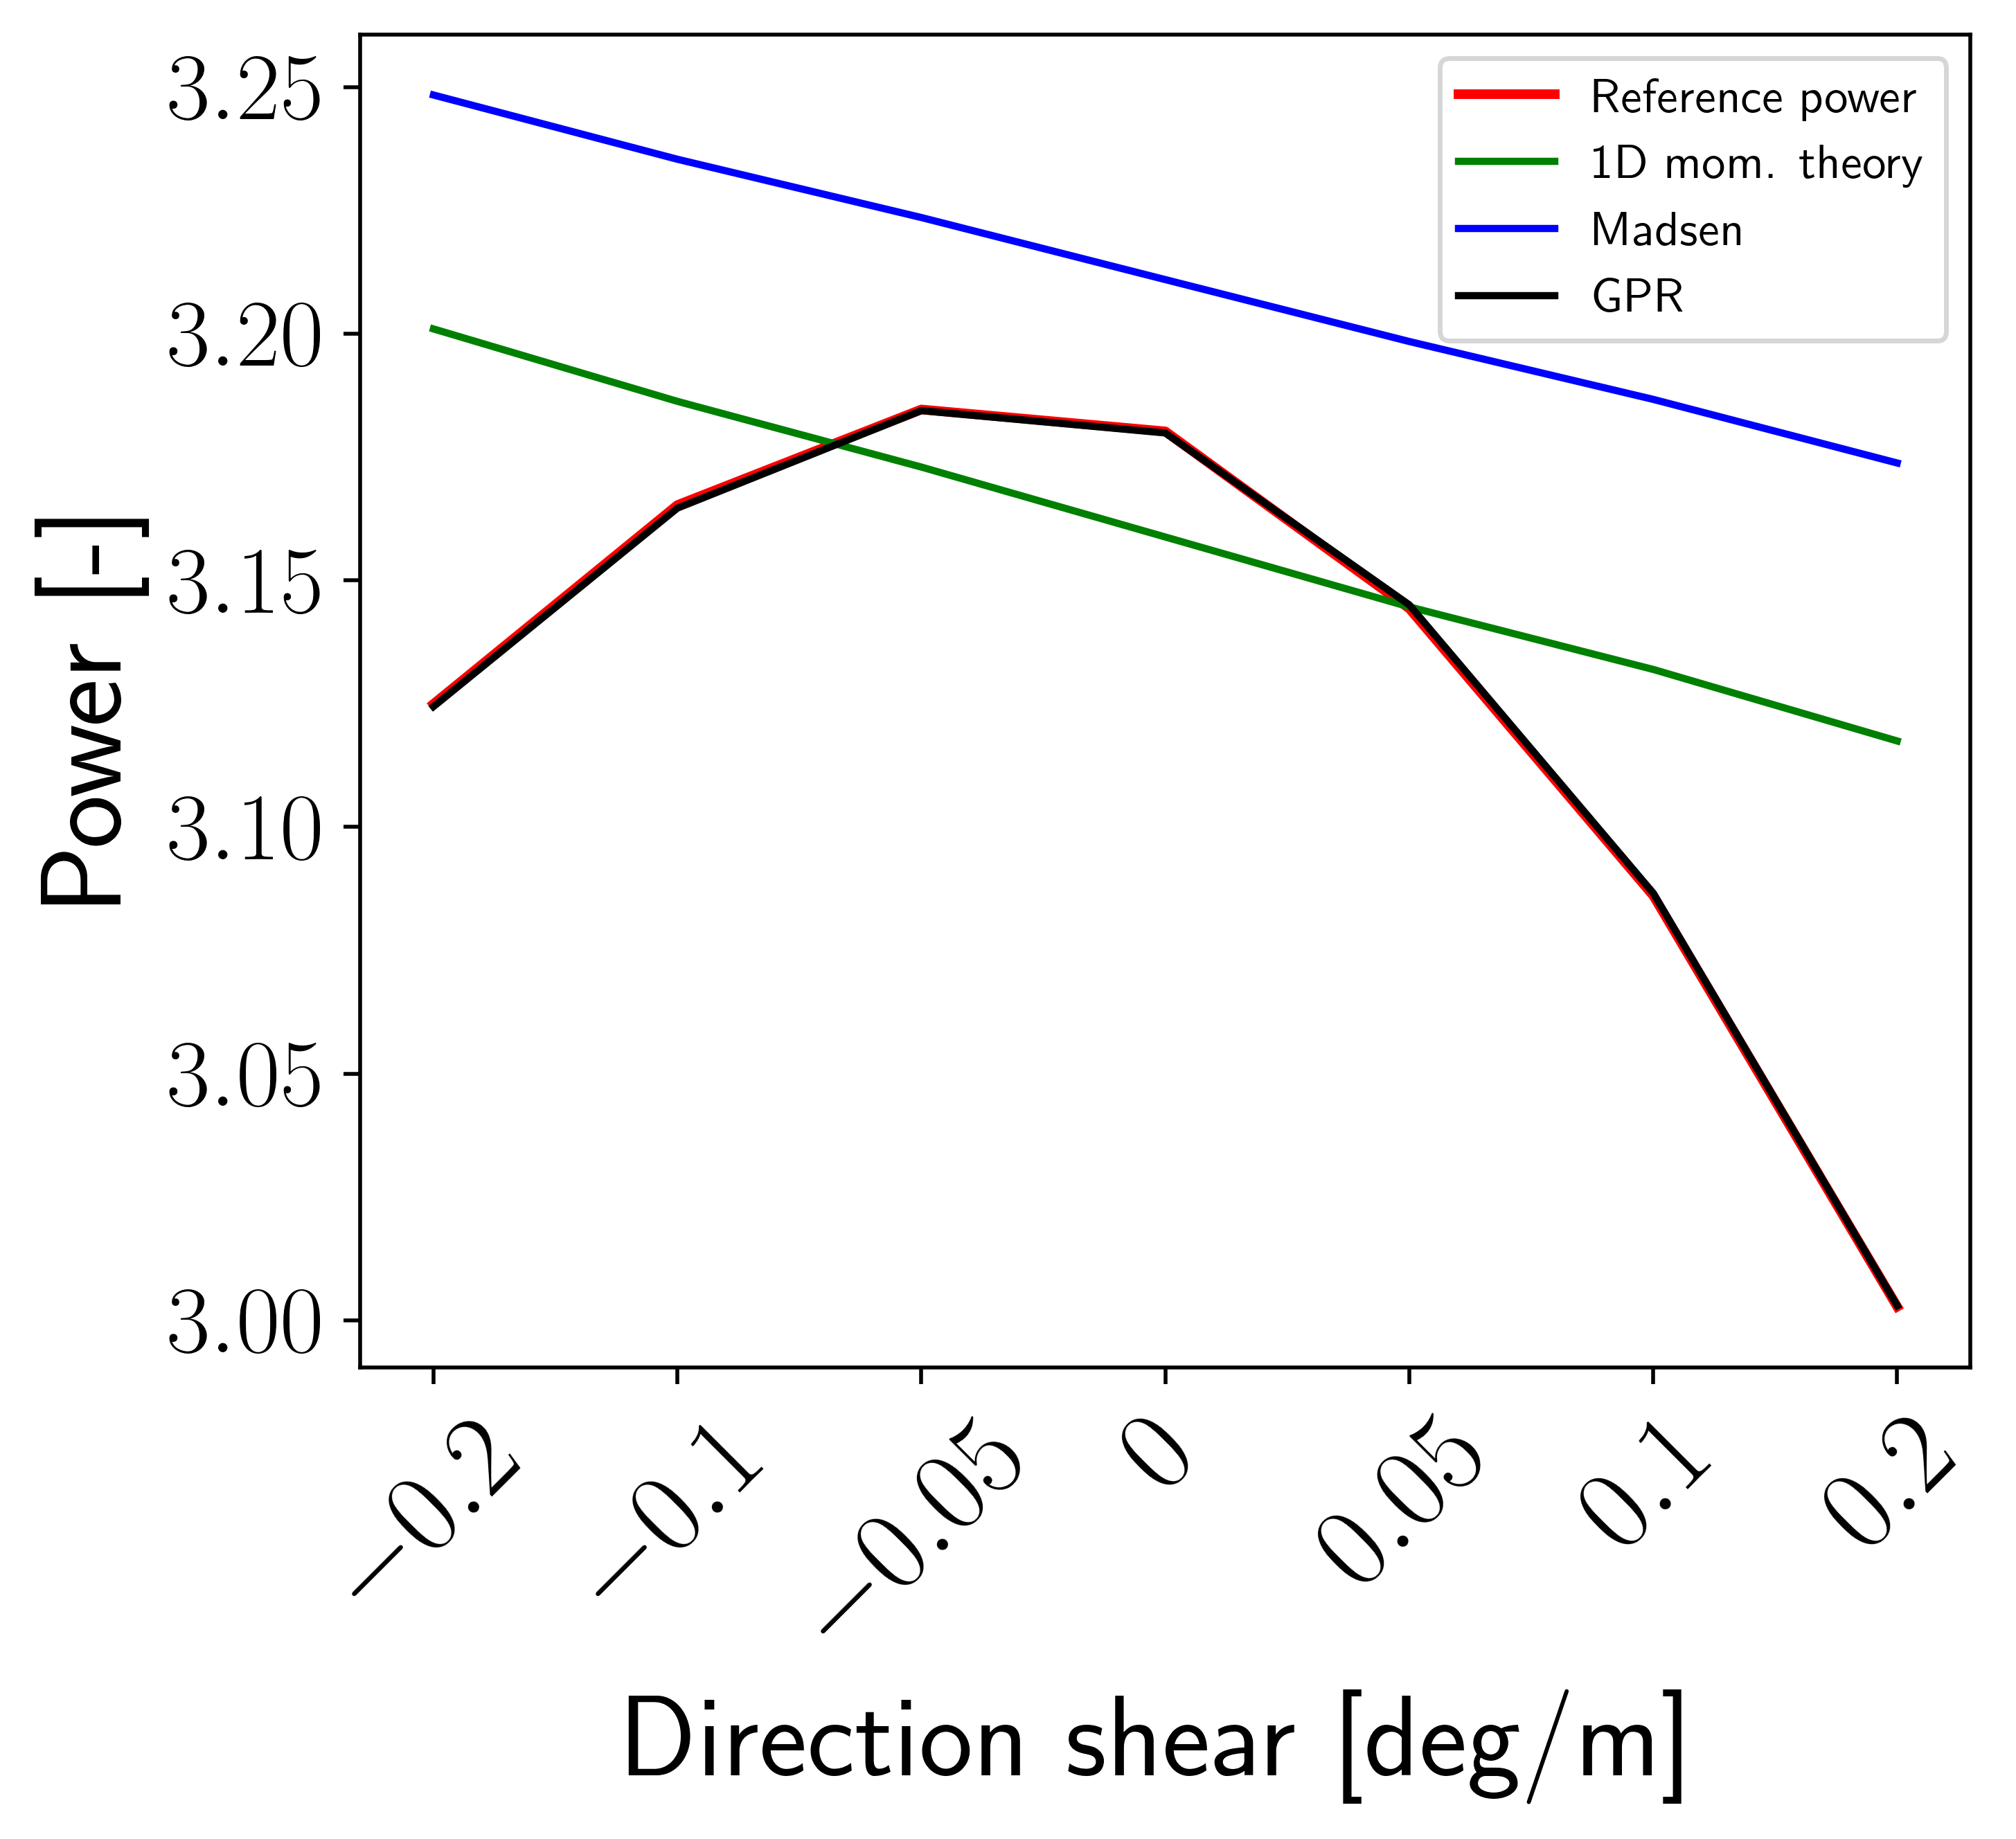

In [22]:
# ROTOR AVERAGE
fig, ax = plt.subplots(figsize=(6, 5))

rated = 1

ax.plot(base_les_pow/rated, color='r', label='Reference power', linewidth=2)
ax.plot(base_1D_pow/rated, color='g', label='1D mom. theory')
ax.plot(base_mad_pow/rated, color='b', label='Madsen')
ax.plot(gpr_pow/rated , color='k', label='GPR')
ax.legend(fontsize=10)

ax.set_ylabel('Power [-]',fontsize=fontsize)
ax.set_xlabel('Direction shear [deg/m]',fontsize=fontsize)

# ax.set_ylim([3.2,3.55])

# ax.set_yscale('log')

tick_positions = [0,1,2,3,4,5,6]  # indices along the x-axis
tick_labels = ['$-0.2$', '$-0.1$', '$-0.05$', '$0$', '$0.05$', '$0.1$', '$0.2$']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=fontsize)

NameError: name 'gpa_pow' is not defined

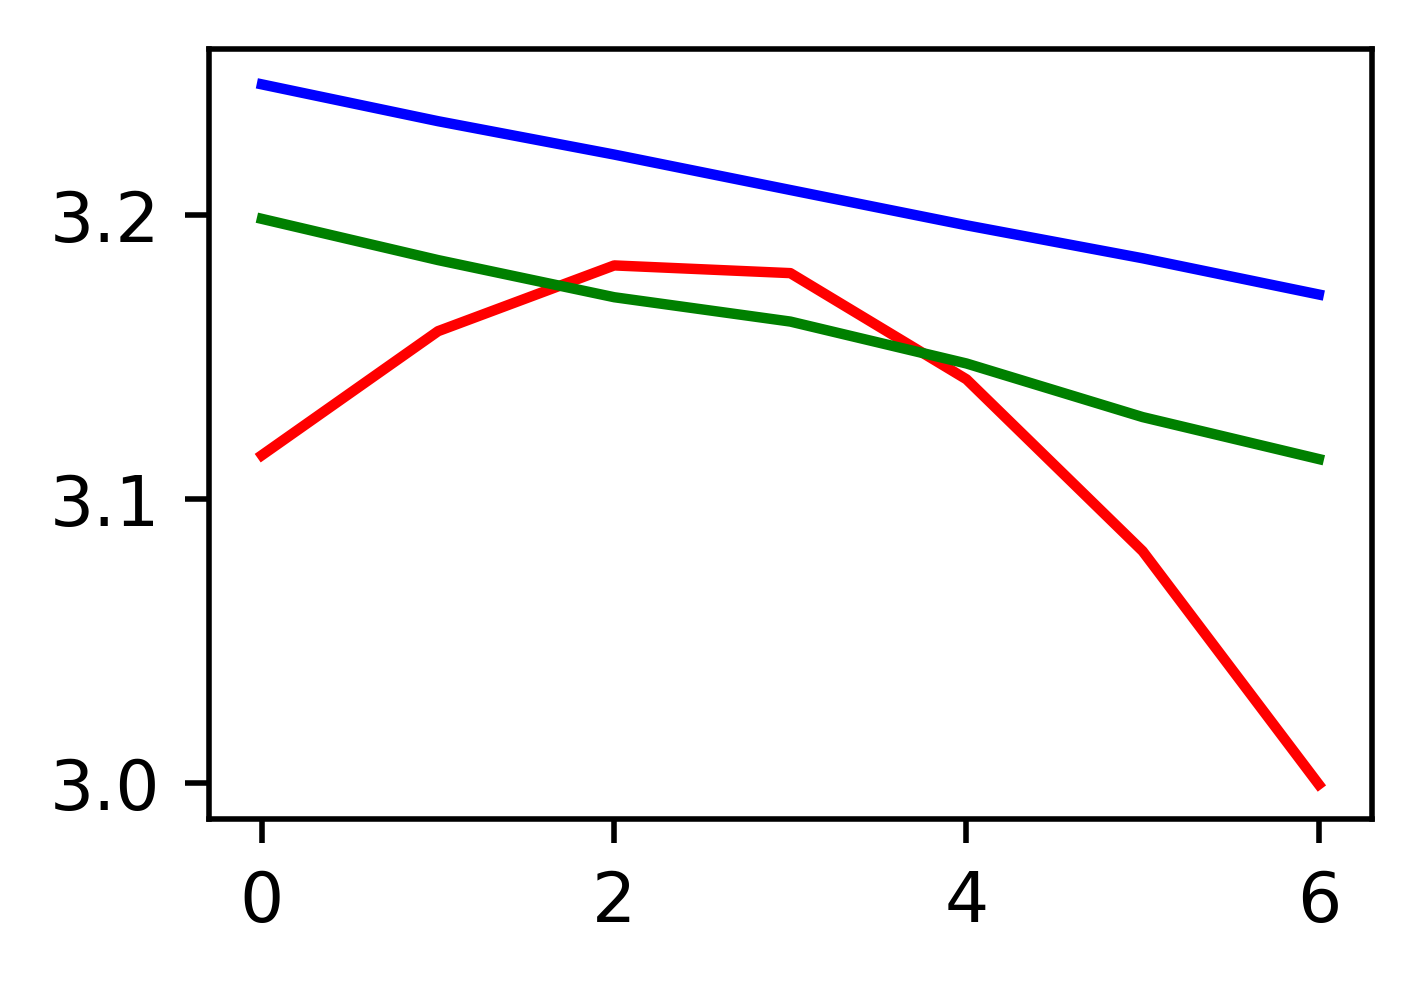

In [48]:
# ANNULUS AVERAGE
fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(base_les_pow/rated, color='r', label='Reference power')
ax.plot(base_1D_pow/rated, color='g', label='1D mom. theory')
ax.plot(base_mad_pow/rated, color='b', label='Madsen')
ax.plot(gpa_pow/rated, color='k', label='GPR')
ax.legend(fontsize=5)

ax.set_ylabel('$P/P_{rated}$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

# ax.set_yscale('log')

# ax.set_ylim([2.75,4.4])

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

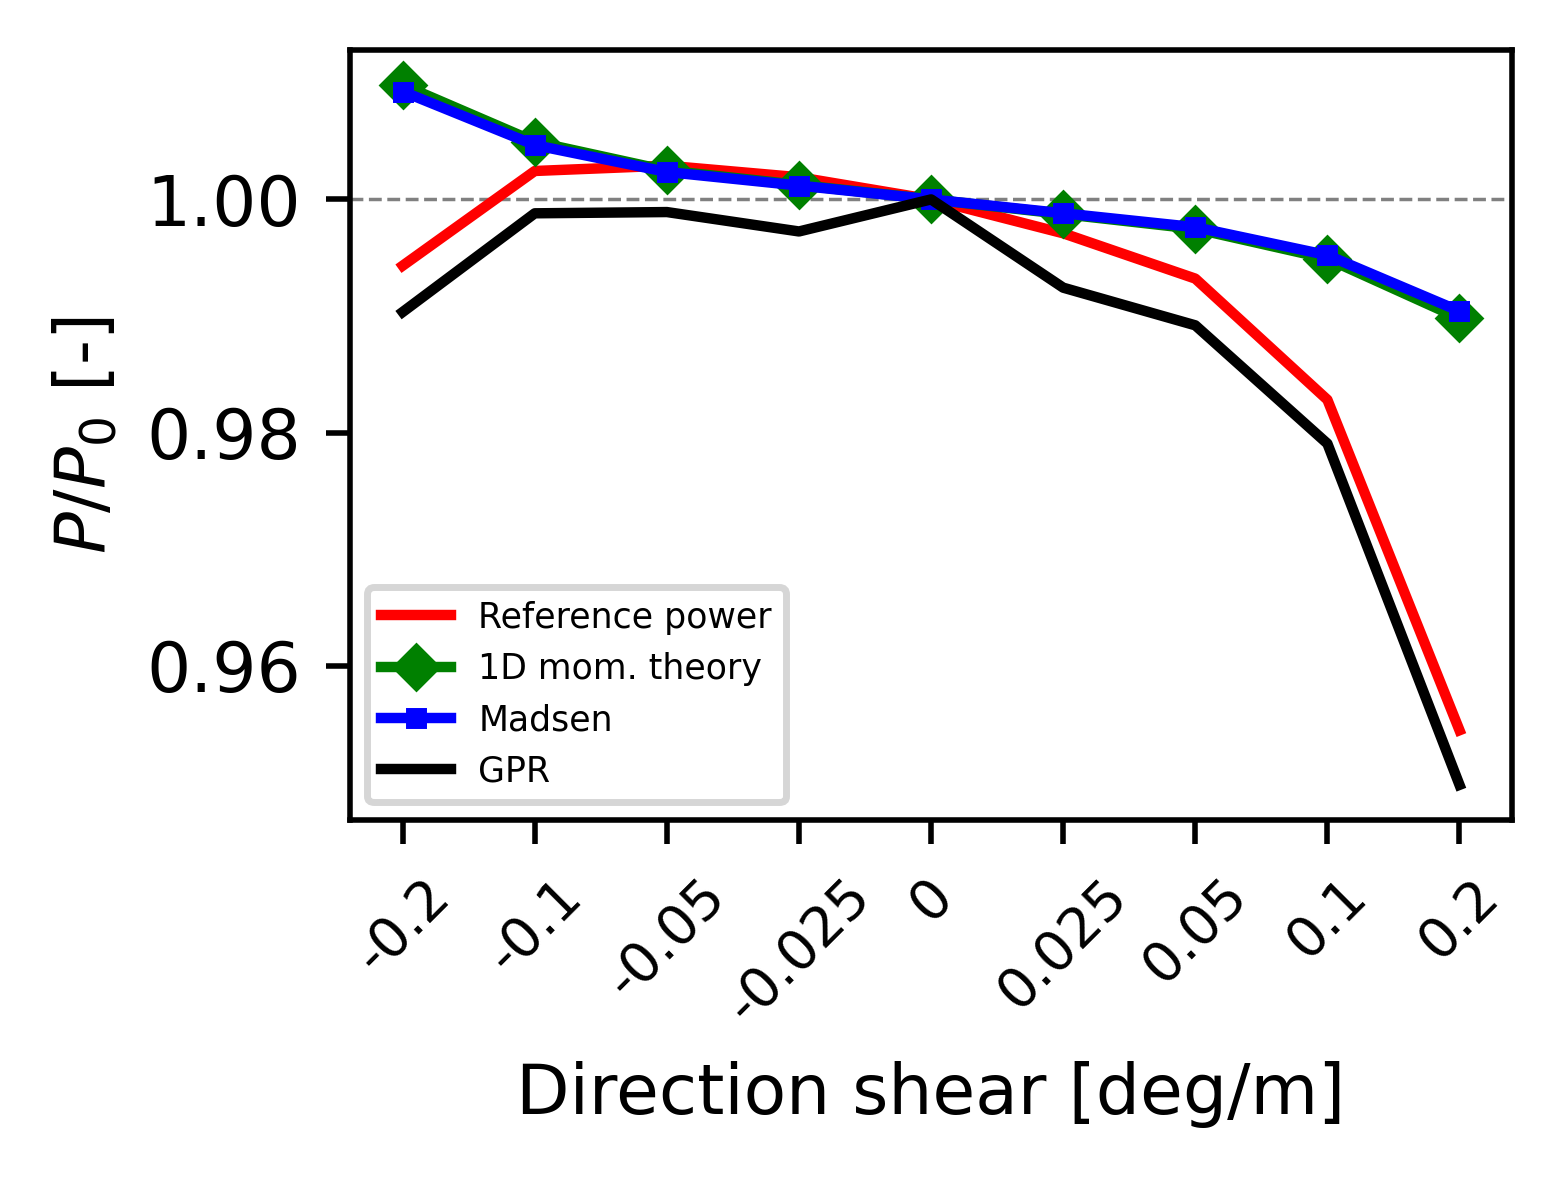

In [170]:
fig, ax = plt.subplots(figsize=(3, 2))

ref_ind = 4

ax.plot(base_les_pow/base_les_pow[ref_ind], color='r', label='Reference power')
ax.plot(base_1D_pow/base_1D_pow[ref_ind], marker='D', markersize=4,color='g', label='1D mom. theory')
ax.plot(base_mad_pow/base_mad_pow[ref_ind], marker = 's', markersize=2, color='b', label='Madsen')
ax.plot(gpa_pow/gpa_pow[ref_ind], color='k', label='GPR')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5,zorder=1)

ax.legend(fontsize=5)

ax.set_ylabel('$P/P_0$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

# ax.set_yscale('log')

In [28]:
(gpa_pow/gpa_pow[ref_ind]-1)*100

array([-0.65292279,  0.2185483 ,  0.24163665,  0.08086076,  0.        ,
       -0.39153415, -0.70979836, -1.7221041 , -4.67194242])

In [29]:
postproc.per_error(gpa_pow,base_les_pow[4])

array([-0.50987934,  0.36284652,  0.38596812,  0.22496074,  0.14398355,
       -0.24811435, -0.5668368 , -1.58060009, -4.5346857 ])

In [ ]:
# Load training data
from scipy.io import loadmat
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_ann.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_ann.mat')
import pickle

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_ann.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_ann.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_ann.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_ann.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

X_rot[:,1] = obj_cot1.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
X_rot[:,2] = obj_cot2.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
X_rot[:,3] = obj_cot3.inverse_transform(X_rot[:,3].reshape(-1, 1)).ravel()
y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,2] = np.round(X_rot[:,2], 3)
X_rot[:,3] = np.round(X_rot[:,3], 3)

uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (v == 0.025 and abs(s) < 0.01)]

In [ ]:
X_rot[0:50,3]

array([-0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,  0.05 ,  0.1  ,
        0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,  0.05 ,
        0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,
        0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,
        0.025,  0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,
        0.   ,  0.025,  0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 ,
       -0.025,  0.   ])

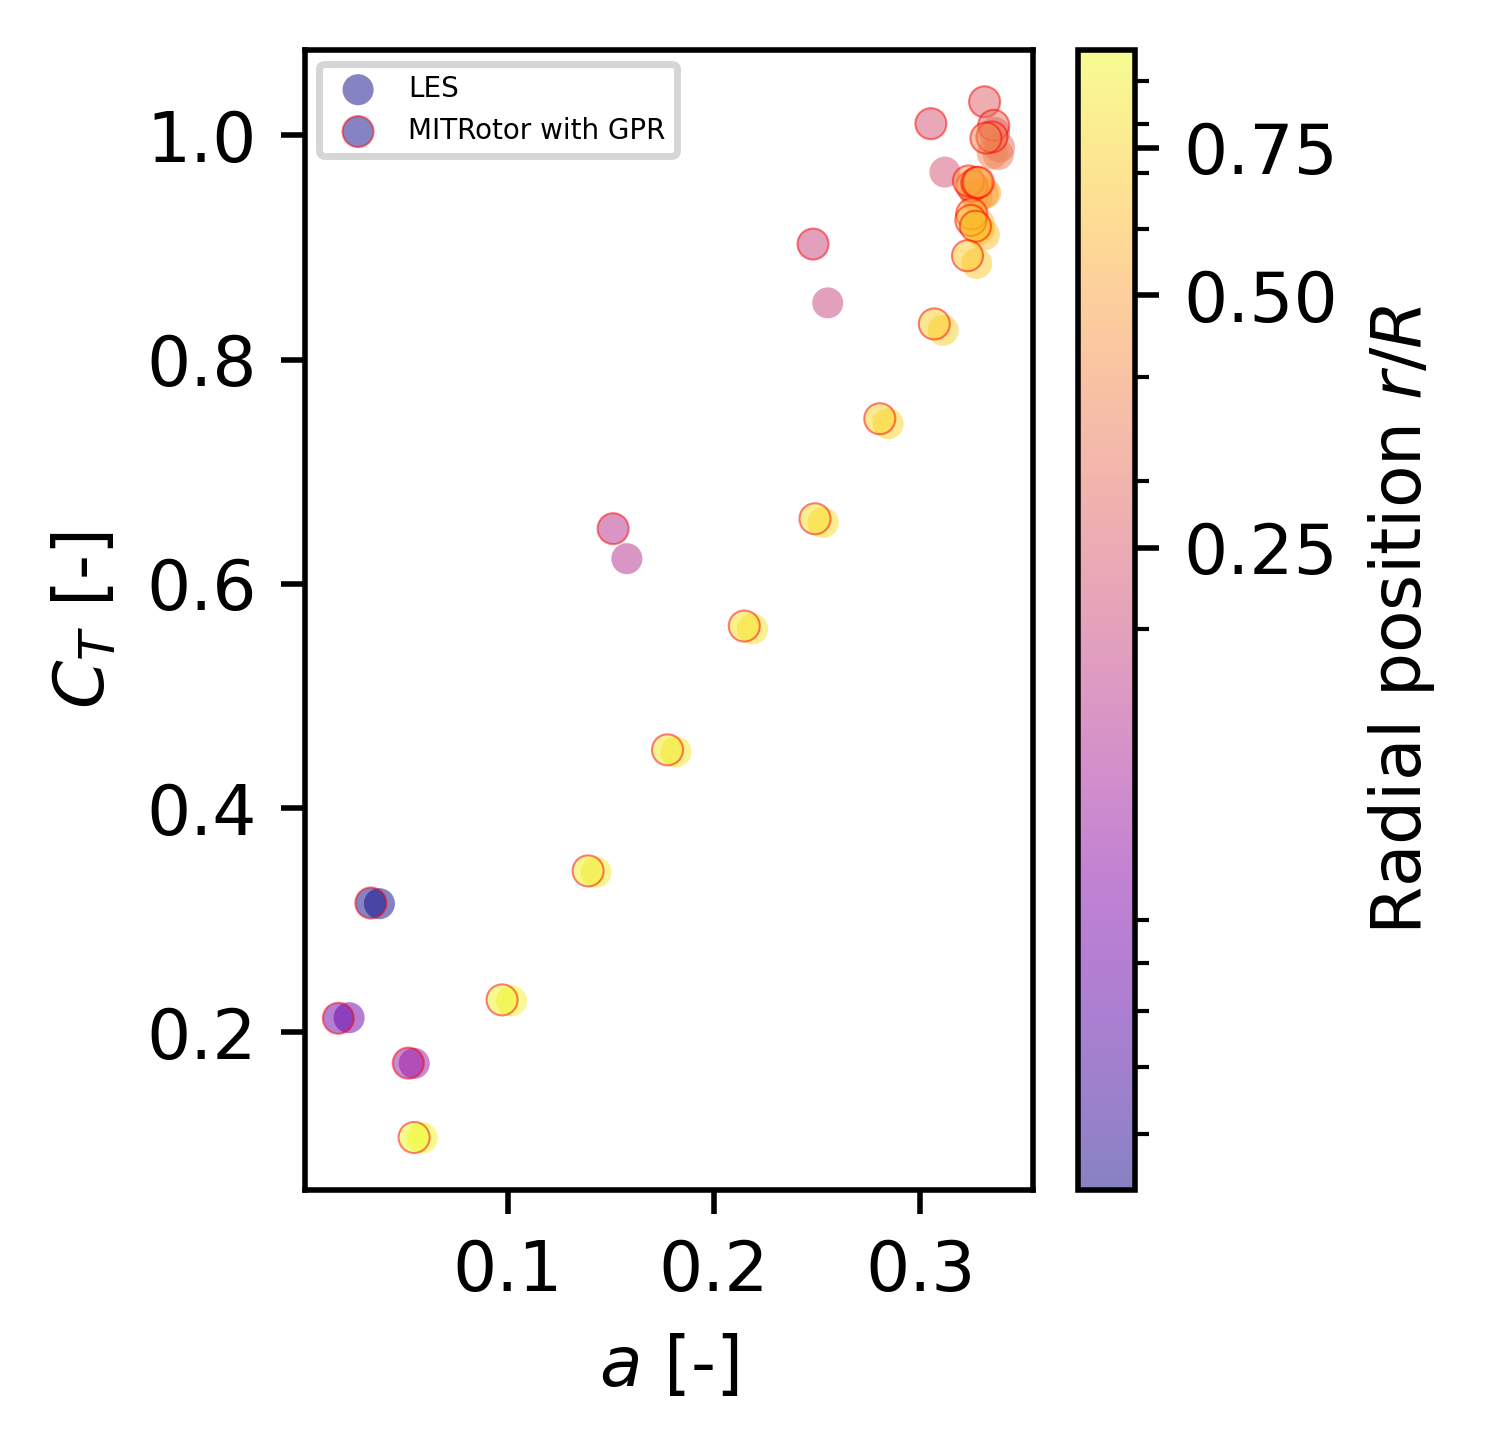

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Select uniform inflow cases (low shear & veer)
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]

# Extract values
r_vals = X_rot[uniform, 0]
a_vals = y_rot[uniform]
ct_vals = X_rot[uniform, 1]

# Create the scatter plot using actual r_vals for color
fig, ax = plt.subplots(figsize=(3, 3))
# sc = ax.scatter(a_vals, ct_vals, s=10, c=r_vals, cmap='viridis', marker='s', edgecolor='none', alpha=1.0)

import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=r_vals.min(), vmax=r_vals.max())

sc = ax.scatter(a_vals, ct_vals, s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='none', linewidth=0.3, alpha=0.5, label='LES')

sc = ax.scatter(gpa_ind_a[:,4], gpa_cot_a[:,4], s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='r', linewidth=0.3, alpha=0.5, label='MITRotor with GPR')

# cbar = plt.colorbar(sc, ax=ax)
cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.5, 0.75])
cbar.set_ticklabels(['0.25', '0.50', '0.75'])  # Optional: format to 2 decimals
cbar.set_label("Radial position $r/R$")

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
ax.legend(fontsize=4)
# ax.set_ylim([0.672,0.6952])

# Add colorbar that reflects radial position r
# cbar = plt.colorbar(sc, ax=ax, pad=0.02)
# cbar.set_label('Radial position $r/R$', fontsize=10)
# cbar.ax.tick_params(labelsize=8)



plt.tight_layout()
plt.show()


Text(0.5, 0, '$a$ [-]')

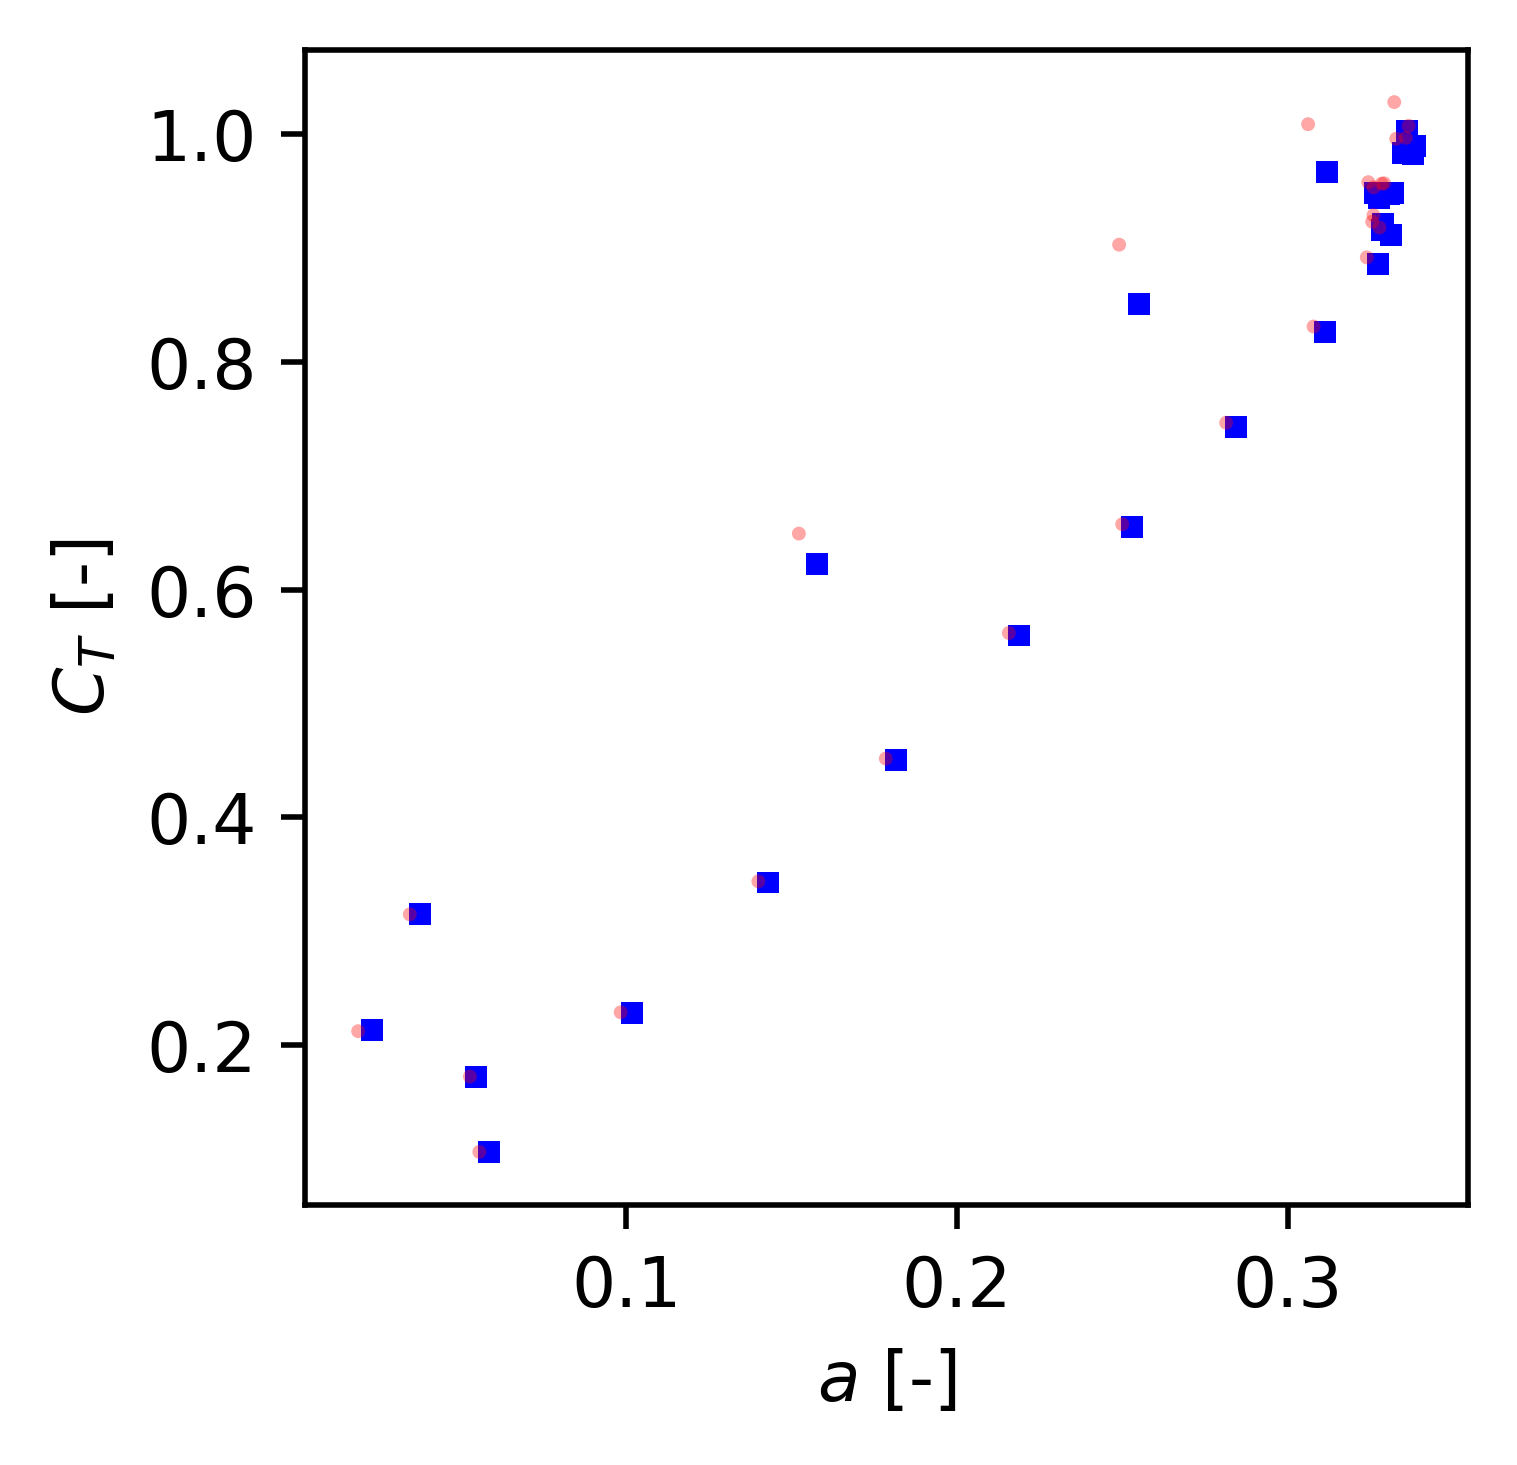

In [ ]:
a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

# uniform = 31

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(y_rot[uniform], X_rot[uniform, 1], s=10, color='b', marker='s', label='Training data', edgecolor='none')
ax.scatter(gpa_ind_a[:,4],  gpa_cot_a[:,4], s=4, color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

Text(0.5, 0, '$a$ [-]')

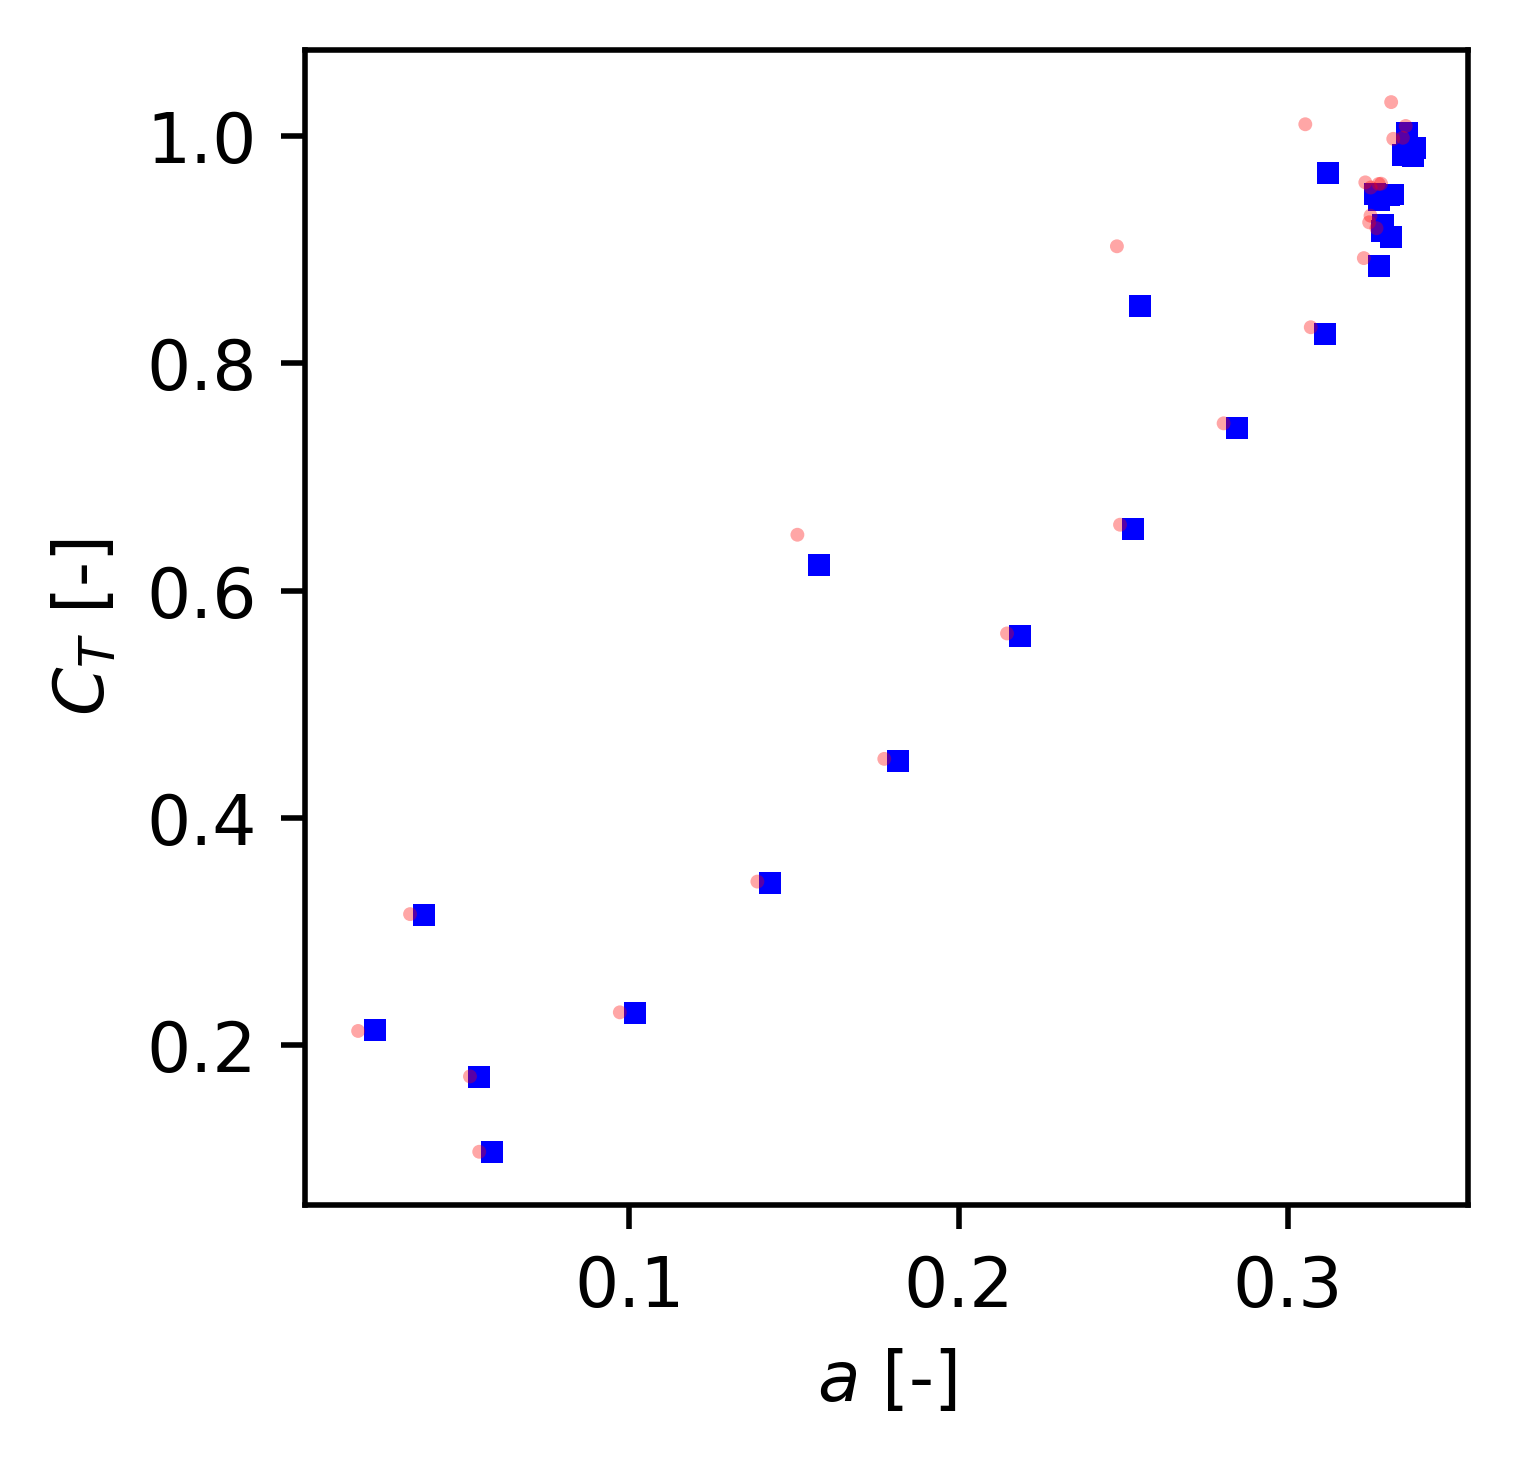

In [ ]:
a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

# uniform = 31

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(y_rot[uniform], X_rot[uniform, 1], s=10, color='b', marker='s', label='Training data', edgecolor='none')
ax.scatter(gpa_ind_a[:,4],  gpa_cot_a[:,4], s=4, color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

In [ ]:
len(uniform)

26